# v1 Stephen Curry career box scores

Research notebook to pull all regular-season Stephen Curry game-level box score rows across his full NBA career.

Context:
- Stephen Curry has played 17 seasons with Golden State.
- Reference checkpoints: 1,065 regular-season games and career averages near 24.8 PTS / 6.3 AST / 4.7 REB.

Goal:
- Resolve Curry's NBA player ID from `nba_api`
- Build full season list from his first to last season
- Pull every regular-season game log season-by-season
- Combine into one DataFrame for downstream modeling and validation

In [1]:
from __future__ import annotations

import ssl
import time
from pathlib import Path

import pandas as pd
import requests
import urllib3

# Repo-standard SSL workaround for nba_api/stats.nba.com calls
# NOTE: this must be set before importing nba_api endpoints.
ssl._create_default_https_context = ssl._create_unverified_context
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

_original_request = requests.Session.request


def _patched_request(self, *args, **kwargs):
    kwargs["verify"] = False
    return _original_request(self, *args, **kwargs)


requests.Session.request = _patched_request

from nba_api.stats.static import players
from nba_api.stats.endpoints import commonplayerinfo
from nba_api.stats.endpoints import playergamelog

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/thomasmyles/.pyenv/versions/3.13.3/lib/python3.13/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/thomasmyles/.pyenv/versions/3.13.3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/thomasmyles/.pyenv/versions/3.13.3/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 340, in dispatch_control
    async with self._control_lock:
               ^^^^^^^^^^^^^^^^^^
  File "/Users/thomasmyles/.pyenv/versions/3.13.3/lib/python3.13/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional


In [2]:
PLAYER_NAME = "Stephen Curry"
SEASON_TYPE = "Regular Season"
RATE_LIMIT_SLEEP_SECONDS = 0.6

In [3]:
def get_player_id_exact(full_name: str) -> int:
    """Return exact NBA API player id for a single player name match."""
    matches = [p for p in players.get_players() if p["full_name"] == full_name]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one match for {full_name}, found {len(matches)}")
    return int(matches[0]["id"])


def build_season_strings(from_year: int, to_year: int) -> list[str]:
    """Build nba_api season strings like 2009-10."""
    return [f"{y}-{str(y + 1)[-2:]}" for y in range(from_year, to_year + 1)]


def fetch_career_regular_season_logs(player_id: int, season_strings: list[str]) -> pd.DataFrame:
    """Fetch one regular-season game log DataFrame per season and combine."""
    season_frames = []
    for i, season in enumerate(season_strings, start=1):
        print(f"[{i}/{len(season_strings)}] fetching {season}")
        frame = playergamelog.PlayerGameLog(
            player_id=player_id,
            season=season,
            season_type_all_star=SEASON_TYPE,
        ).get_data_frames()[0]
        frame["SEASON_STR"] = season
        season_frames.append(frame)
        time.sleep(RATE_LIMIT_SLEEP_SECONDS)

    combined = pd.concat(season_frames, ignore_index=True)
    combined["GAME_DATE"] = pd.to_datetime(combined["GAME_DATE"])
    combined = combined.sort_values("GAME_DATE").reset_index(drop=True)
    return combined

In [4]:
player_id = get_player_id_exact(PLAYER_NAME)

player_info_df = commonplayerinfo.CommonPlayerInfo(player_id=player_id).get_data_frames()[0]
from_year = int(player_info_df["FROM_YEAR"].iloc[0])
to_year = int(player_info_df["TO_YEAR"].iloc[0])

season_strings = build_season_strings(from_year, to_year)
curry_games_df = fetch_career_regular_season_logs(player_id=player_id, season_strings=season_strings)

print(f"Player ID: {player_id}")
print(f"Season span: {season_strings[0]} -> {season_strings[-1]} ({len(season_strings)} seasons)")
print(f"Regular-season games fetched: {len(curry_games_df):,}")
print(f"Date range: {curry_games_df['GAME_DATE'].min().date()} -> {curry_games_df['GAME_DATE'].max().date()}")

[1/17] fetching 2009-10
[2/17] fetching 2010-11
[3/17] fetching 2011-12
[4/17] fetching 2012-13
[5/17] fetching 2013-14
[6/17] fetching 2014-15
[7/17] fetching 2015-16
[8/17] fetching 2016-17
[9/17] fetching 2017-18
[10/17] fetching 2018-19
[11/17] fetching 2019-20
[12/17] fetching 2020-21
[13/17] fetching 2021-22
[14/17] fetching 2022-23
[15/17] fetching 2023-24
[16/17] fetching 2024-25
[17/17] fetching 2025-26
Player ID: 201939
Season span: 2009-10 -> 2025-26 (17 seasons)
Regular-season games fetched: 1,065
Date range: 2009-10-28 -> 2026-01-30


In [5]:
career_summary = pd.Series(
    {
        "games": int(len(curry_games_df)),
        "avg_pts": float(curry_games_df["PTS"].mean()),
        "avg_ast": float(curry_games_df["AST"].mean()),
        "avg_reb": float(curry_games_df["REB"].mean()),
        "avg_fg3m": float(curry_games_df["FG3M"].mean()),
    }
).round(2)

career_summary

games       1065.00
avg_pts       24.83
avg_ast        6.32
avg_reb        4.65
avg_fg3m       3.97
dtype: float64

In [6]:
output_path = Path("/Users/thomasmyles/dev/betting/tmp/stephen_curry_career_regular_season_box_scores.csv")
curry_games_df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: /Users/thomasmyles/dev/betting/tmp/stephen_curry_career_regular_season_box_scores.csv


In [7]:
display_columns = [
    "GAME_DATE",
    "MATCHUP",
    "WL",
    "MIN",
    "PTS",
    "REB",
    "AST",
    "FGM",
    "FGA",
    "FG3M",
    "FG3A",
    "FTM",
    "FTA",
    "PLUS_MINUS",
    "SEASON_ID",
    "SEASON_STR",
]

curry_games_df[display_columns].tail(20)

,GAME_DATE,MATCHUP,WL,MIN,PTS,REB,AST,FGM,FGA,FG3M,FG3A,FTM,FTA,PLUS_MINUS,SEASON_ID,SEASON_STR
1045,2025-12-20,GSW vs. PHX,W,35,28,10,6,9,19,4,11,6,7,13,22025,2025-26
1046,2025-12-22,GSW vs. ORL,W,31,26,3,6,10,23,4,13,2,2,17,22025,2025-26
1047,2025-12-25,GSW vs. DAL,W,33,23,3,4,6,18,2,10,9,9,-3,22025,2025-26
1048,2025-12-28,GSW @ TOR,L,41,39,3,4,12,30,4,11,11,11,0,22025,2025-26
1049,2025-12-29,GSW @ BKN,W,29,27,2,5,8,15,5,12,6,7,-6,22025,2025-26
1050,2025-12-31,GSW @ CHA,W,33,26,2,4,9,16,5,10,3,3,11,22025,2025-26
1051,2026-01-03,GSW vs. UTA,W,34,31,2,5,8,18,6,12,9,9,5,22025,2025-26
1052,2026-01-05,GSW @ LAC,L,34,27,4,6,9,23,4,15,5,5,5,22025,2025-26
1053,2026-01-07,GSW vs. MIL,W,34,31,6,7,12,21,3,9,4,5,16,22025,2025-26
1054,2026-01-09,GSW vs. SAC,W,32,27,0,10,10,21,6,12,1,1,14,22025,2025-26


In [8]:
curry_games_df.columns

Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'SEASON_STR'],
      dtype='object')

In [9]:
# running this:

# python "tmp/fetch_steph_curry_career_box_scores.py" --player "Stephen Curry" --include-player-info

In [10]:
# Compare columns available in tmp export vs columns currently in your notebook DataFrame.
# Assumes your notebook DataFrame is named `curry_games_df`.
# If your df has a different name, replace it below.

import pandas as pd

columns_inventory_path = "/Users/thomasmyles/dev/betting/tmp/stephen_curry_career_box_scores_columns.csv"

inventory_df = pd.read_csv(columns_inventory_path)
available_columns = set(inventory_df["column_name"].tolist())
current_columns = set(curry_games_df.columns.tolist())

missing_in_notebook = sorted(available_columns - current_columns)
already_in_notebook = sorted(available_columns & current_columns)

print(f"Available in tmp export: {len(available_columns)}")
print(f"Currently in notebook df: {len(current_columns)}")
print(f"Missing in notebook: {len(missing_in_notebook)}")

print("\n--- Missing columns (copy from here) ---")
for col in missing_in_notebook:
    print(col)

# Optional quick view
pd.DataFrame({"missing_column": missing_in_notebook}).head(50)

Available in tmp export: 61
Currently in notebook df: 28
Missing in notebook: 33

--- Missing columns (copy from here) ---
PLAYER_INFO_BIRTHDATE
PLAYER_INFO_COUNTRY
PLAYER_INFO_DISPLAY_FIRST_LAST
PLAYER_INFO_DISPLAY_FI_LAST
PLAYER_INFO_DISPLAY_LAST_COMMA_FIRST
PLAYER_INFO_DLEAGUE_FLAG
PLAYER_INFO_DRAFT_NUMBER
PLAYER_INFO_DRAFT_ROUND
PLAYER_INFO_DRAFT_YEAR
PLAYER_INFO_FIRST_NAME
PLAYER_INFO_FROM_YEAR
PLAYER_INFO_GAMES_PLAYED_CURRENT_SEASON_FLAG
PLAYER_INFO_GAMES_PLAYED_FLAG
PLAYER_INFO_GREATEST_75_FLAG
PLAYER_INFO_HEIGHT
PLAYER_INFO_JERSEY
PLAYER_INFO_LAST_AFFILIATION
PLAYER_INFO_LAST_NAME
PLAYER_INFO_NBA_FLAG
PLAYER_INFO_PERSON_ID
PLAYER_INFO_PLAYERCODE
PLAYER_INFO_PLAYER_SLUG
PLAYER_INFO_POSITION
PLAYER_INFO_ROSTERSTATUS
PLAYER_INFO_SCHOOL
PLAYER_INFO_SEASON_EXP
PLAYER_INFO_TEAM_ABBREVIATION
PLAYER_INFO_TEAM_CITY
PLAYER_INFO_TEAM_CODE
PLAYER_INFO_TEAM_ID
PLAYER_INFO_TEAM_NAME
PLAYER_INFO_TO_YEAR
PLAYER_INFO_WEIGHT


,missing_column
0,PLAYER_INFO_BIRTHDATE
1,PLAYER_INFO_COUNTRY
2,PLAYER_INFO_DISPLAY_FIRST_LAST
3,PLAYER_INFO_DISPLAY_FI_LAST
4,PLAYER_INFO_DISPLAY_LAST_COMMA_FIRST
5,PLAYER_INFO_DLEAGUE_FLAG
6,PLAYER_INFO_DRAFT_NUMBER
7,PLAYER_INFO_DRAFT_ROUND
8,PLAYER_INFO_DRAFT_YEAR
9,PLAYER_INFO_FIRST_NAME


In [11]:
inventory_df

,column_name,dtype,non_null_count
0,SEASON_ID,object,1065
1,Player_ID,int64,1065
2,Game_ID,object,1065
3,GAME_DATE,datetime64[ns],1065
4,MATCHUP,object,1065
...,...,...,...
56,PLAYER_INFO_GAMES_PLAYED_FLAG,object,1065
57,PLAYER_INFO_DRAFT_YEAR,object,1065
58,PLAYER_INFO_DRAFT_ROUND,object,1065
59,PLAYER_INFO_DRAFT_NUMBER,object,1065


In [12]:
# doing the above in here:

import subprocess
import pandas as pd

subprocess.run(
    [
        "python",
        "/Users/thomasmyles/dev/betting/tmp/fetch_steph_curry_career_box_scores.py",
        "--player",
        "Stephen Curry",
        "--include-player-info",
    ],
    check=True,
)

curry_games_df = pd.read_csv(
    "/Users/thomasmyles/dev/betting/tmp/stephen_curry_career_box_scores.csv"
)
curry_games_df["GAME_DATE"] = pd.to_datetime(curry_games_df["GAME_DATE"])

print("shape:", curry_games_df.shape)
print("column_count:", len(curry_games_df.columns))
print("player_info_cols:", len([c for c in curry_games_df.columns if c.startswith("PLAYER_INFO_")]))
curry_games_df.head(3)

[1/17] fetching 2009-10
[2/17] fetching 2010-11
[3/17] fetching 2011-12
[4/17] fetching 2012-13
[5/17] fetching 2013-14
[6/17] fetching 2014-15
[7/17] fetching 2015-16
[8/17] fetching 2016-17
[9/17] fetching 2017-18
[10/17] fetching 2018-19
[11/17] fetching 2019-20
[12/17] fetching 2020-21
[13/17] fetching 2021-22
[14/17] fetching 2022-23
[15/17] fetching 2023-24
[16/17] fetching 2024-25
[17/17] fetching 2025-26

player_id: 201939
season_span: 2009-10 -> 2025-26 (17 seasons, Regular Season)
games: 1065
avg_pts/ast/reb: 24.83/6.32/4.65
column_count: 61
saved_csv: /Users/thomasmyles/dev/betting/tmp/stephen_curry_career_box_scores.csv
saved_columns_inventory: /Users/thomasmyles/dev/betting/tmp/stephen_curry_career_box_scores_columns.csv
shape: (1065, 61)
column_count: 61
player_info_cols: 33


,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,PLAYER_INFO_PLAYERCODE,PLAYER_INFO_FROM_YEAR,PLAYER_INFO_TO_YEAR,PLAYER_INFO_DLEAGUE_FLAG,PLAYER_INFO_NBA_FLAG,PLAYER_INFO_GAMES_PLAYED_FLAG,PLAYER_INFO_DRAFT_YEAR,PLAYER_INFO_DRAFT_ROUND,PLAYER_INFO_DRAFT_NUMBER,PLAYER_INFO_GREATEST_75_FLAG
0,22009,201939,20900015,2009-10-28,GSW vs. HOU,L,36,7,12,0.583,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
1,22009,201939,20900030,2009-10-30,GSW @ PHX,L,39,5,9,0.556,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
2,22009,201939,20900069,2009-11-04,GSW vs. MEM,W,28,3,6,0.500,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y


In [13]:
curry_games_df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,PLAYER_INFO_PLAYERCODE,PLAYER_INFO_FROM_YEAR,PLAYER_INFO_TO_YEAR,PLAYER_INFO_DLEAGUE_FLAG,PLAYER_INFO_NBA_FLAG,PLAYER_INFO_GAMES_PLAYED_FLAG,PLAYER_INFO_DRAFT_YEAR,PLAYER_INFO_DRAFT_ROUND,PLAYER_INFO_DRAFT_NUMBER,PLAYER_INFO_GREATEST_75_FLAG
0,22009,201939,20900015,2009-10-28,GSW vs. HOU,L,36,7,12,0.583,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
1,22009,201939,20900030,2009-10-30,GSW @ PHX,L,39,5,9,0.556,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
2,22009,201939,20900069,2009-11-04,GSW vs. MEM,W,28,3,6,0.500,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
3,22009,201939,20900082,2009-11-06,GSW vs. LAC,L,22,1,5,0.200,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
4,22009,201939,20900096,2009-11-08,GSW @ SAC,L,31,4,8,0.500,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,22025,201939,22500618,2026-01-20,GSW vs. TOR,L,25,6,16,0.375,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
1061,22025,201939,22500630,2026-01-22,GSW @ DAL,L,34,14,27,0.519,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
1062,22025,201939,22500644,2026-01-25,GSW @ MIN,W,28,7,18,0.389,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y
1063,22025,201939,22500678,2026-01-28,GSW @ UTA,W,28,7,14,0.500,...,stephen_curry,2009,2025,N,Y,Y,2009,1,7,Y


In [14]:
curry_games_df.to_dict('records')[0]

{'SEASON_ID': 22009,
 'Player_ID': 201939,
 'Game_ID': 20900015,
 'GAME_DATE': Timestamp('2009-10-28 00:00:00'),
 'MATCHUP': 'GSW vs. HOU',
 'WL': 'L',
 'MIN': 36,
 'FGM': 7,
 'FGA': 12,
 'FG_PCT': 0.583,
 'FG3M': 0,
 'FG3A': 1,
 'FG3_PCT': 0.0,
 'FTM': 0,
 'FTA': 0,
 'FT_PCT': 0.0,
 'OREB': 1,
 'DREB': 1,
 'REB': 2,
 'AST': 7,
 'STL': 4,
 'BLK': 0,
 'TOV': 2,
 'PF': 2,
 'PTS': 14,
 'PLUS_MINUS': 7,
 'VIDEO_AVAILABLE': 0,
 'SEASON_STR': '2009-10',
 'PLAYER_INFO_PERSON_ID': 201939,
 'PLAYER_INFO_FIRST_NAME': 'Stephen',
 'PLAYER_INFO_LAST_NAME': 'Curry',
 'PLAYER_INFO_DISPLAY_FIRST_LAST': 'Stephen Curry',
 'PLAYER_INFO_DISPLAY_LAST_COMMA_FIRST': 'Curry, Stephen',
 'PLAYER_INFO_DISPLAY_FI_LAST': 'S. Curry',
 'PLAYER_INFO_PLAYER_SLUG': 'stephen-curry',
 'PLAYER_INFO_BIRTHDATE': '1988-03-14T00:00:00',
 'PLAYER_INFO_SCHOOL': 'Davidson',
 'PLAYER_INFO_COUNTRY': 'USA',
 'PLAYER_INFO_LAST_AFFILIATION': 'Davidson/USA',
 'PLAYER_INFO_HEIGHT': '6-2',
 'PLAYER_INFO_WEIGHT': 185,
 'PLAYER_INFO_SEASO

In [15]:
curry_games_df.to_dict('records')[-1]

{'SEASON_ID': 22025,
 'Player_ID': 201939,
 'Game_ID': 22500696,
 'GAME_DATE': Timestamp('2026-01-30 00:00:00'),
 'MATCHUP': 'GSW vs. DET',
 'WL': 'L',
 'MIN': 25,
 'FGM': 7,
 'FGA': 16,
 'FG_PCT': 0.438,
 'FG3M': 4,
 'FG3A': 10,
 'FG3_PCT': 0.4,
 'FTM': 5,
 'FTA': 5,
 'FT_PCT': 1.0,
 'OREB': 0,
 'DREB': 1,
 'REB': 1,
 'AST': 2,
 'STL': 0,
 'BLK': 1,
 'TOV': 4,
 'PF': 0,
 'PTS': 23,
 'PLUS_MINUS': -5,
 'VIDEO_AVAILABLE': 1,
 'SEASON_STR': '2025-26',
 'PLAYER_INFO_PERSON_ID': 201939,
 'PLAYER_INFO_FIRST_NAME': 'Stephen',
 'PLAYER_INFO_LAST_NAME': 'Curry',
 'PLAYER_INFO_DISPLAY_FIRST_LAST': 'Stephen Curry',
 'PLAYER_INFO_DISPLAY_LAST_COMMA_FIRST': 'Curry, Stephen',
 'PLAYER_INFO_DISPLAY_FI_LAST': 'S. Curry',
 'PLAYER_INFO_PLAYER_SLUG': 'stephen-curry',
 'PLAYER_INFO_BIRTHDATE': '1988-03-14T00:00:00',
 'PLAYER_INFO_SCHOOL': 'Davidson',
 'PLAYER_INFO_COUNTRY': 'USA',
 'PLAYER_INFO_LAST_AFFILIATION': 'Davidson/USA',
 'PLAYER_INFO_HEIGHT': '6-2',
 'PLAYER_INFO_WEIGHT': 185,
 'PLAYER_INFO_SEA

In [16]:
# start on regression modeling (research phase)


In [17]:
# using curry data only

In [18]:
# 2025-26 season

In [19]:
curry_games_df_2025_26 = curry_games_df[curry_games_df["SEASON_STR"] == "2025-26"]
curry_games_df_2025_26.shape

(39, 61)

In [20]:
# Cell 1: prep Curry 2025-26 data
import numpy as np
import pandas as pd

season_df = (
    curry_games_df[curry_games_df["SEASON_STR"] == "2025-26"]
    .copy()
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

season_df["GAME_DATE"] = pd.to_datetime(season_df["GAME_DATE"])
season_df["FG3M"] = season_df["FG3M"].astype(float)

print("rows:", len(season_df))
season_df[["GAME_DATE", "FG3M"]].head()

rows: 39


,GAME_DATE,FG3M
0,2025-10-21,3.0
1,2025-10-23,6.0
2,2025-10-24,7.0
3,2025-10-27,4.0
4,2025-10-28,2.0


In [21]:
# Cell 2: build feature = lagged running mean of last 100 games
# (for 2025-26 Curry this behaves like an expanding mean)

season_df["x_last100_mean_3pm"] = (
    season_df["FG3M"]
    .rolling(window=100, min_periods=1)
    .mean()
    .shift(1)  # lag so current game is not used in its own feature
)

model_df = season_df.dropna(subset=["x_last100_mean_3pm"]).copy()

print("model rows:", len(model_df))
model_df[["GAME_DATE", "FG3M", "x_last100_mean_3pm"]].head(10)

model rows: 38


,GAME_DATE,FG3M,x_last100_mean_3pm
1,2025-10-23,6.0,3.000000
2,2025-10-24,7.0,4.500000
3,2025-10-27,4.0,5.333333
4,2025-10-28,2.0,5.000000
5,2025-10-30,4.0,4.400000
6,2025-11-01,4.0,4.333333
7,2025-11-04,5.0,4.285714
8,2025-11-11,1.0,4.375000
9,2025-11-12,5.0,4.000000
10,2025-11-14,9.0,4.100000


In [22]:
# Cell 3: fit simple OLS  y = b0 + b1*x
x = model_df["x_last100_mean_3pm"].to_numpy(dtype=float)
y = model_df["FG3M"].to_numpy(dtype=float)

X = np.column_stack([np.ones(len(x)), x])
b0, b1 = np.linalg.lstsq(X, y, rcond=None)[0]

model_df["y_hat"] = b0 + b1 * model_df["x_last100_mean_3pm"]
model_df["residual"] = model_df["FG3M"] - model_df["y_hat"]

rmse = float(np.sqrt(np.mean((model_df["FG3M"] - model_df["y_hat"]) ** 2)))
ss_res = float(np.sum((model_df["FG3M"] - model_df["y_hat"]) ** 2))
ss_tot = float(np.sum((model_df["FG3M"] - model_df["FG3M"].mean()) ** 2))
r2 = 1.0 - (ss_res / ss_tot)

print(f"intercept (b0): {b0:.4f}")
print(f"x_last100_mean_3pm coef (b1): {b1:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

model_df[["GAME_DATE", "FG3M", "x_last100_mean_3pm", "y_hat", "residual"]]#.tail(12)

intercept (b0): 12.3476
x_last100_mean_3pm coef (b1): -1.7006
RMSE: 2.2704
R2: 0.0737


,GAME_DATE,FG3M,x_last100_mean_3pm,y_hat,residual
1,2025-10-23,6.0,3.000000,7.245840,-1.245840
2,2025-10-24,7.0,4.500000,4.694946,2.305054
3,2025-10-27,4.0,5.333333,3.277782,0.722218
4,2025-10-28,2.0,5.000000,3.844648,-1.844648
5,2025-10-30,4.0,4.400000,4.865005,-0.865005
6,2025-11-01,4.0,4.333333,4.978378,-0.978378
7,2025-11-04,5.0,4.285714,5.059359,-0.059359
8,2025-11-11,1.0,4.375000,4.907520,-3.907520
9,2025-11-12,5.0,4.000000,5.545244,-0.545244
10,2025-11-14,9.0,4.100000,5.375184,3.624816


explanation:
- Model equation
    - Predicted 3PM = 12.3476 + (-1.7006 * last100_mean_3pm)
- b1 = -1.7006 (negative slope)
    - As the running mean input goes up by 1, model prediction goes down by about 1.70 threes.
    - That is counterintuitive for this problem and usually signals instability/noise in a small sample (or mean-reversion behavior dominating).
- b0 = 12.3476 (intercept)
    - This is the prediction when input is 0.
    - Not directly meaningful in basketball terms because Curry’s running mean is never near 0; it mostly balances the negative slope so predictions land in a realistic range.
- RMSE = 2.2704
    - Typical prediction error is about 2.27 made threes per game.
    - On a target like FG3M, that’s fairly large.
- R2 = 0.0737
    - The model explains only about 7.4% of game-to-game variance.
    - So this single-feature setup has weak predictive power on this sample.

Bottom line: this fit is weak and likely unstable; good signal that you need more features and/or walk-forward fitting with coefficient tracking

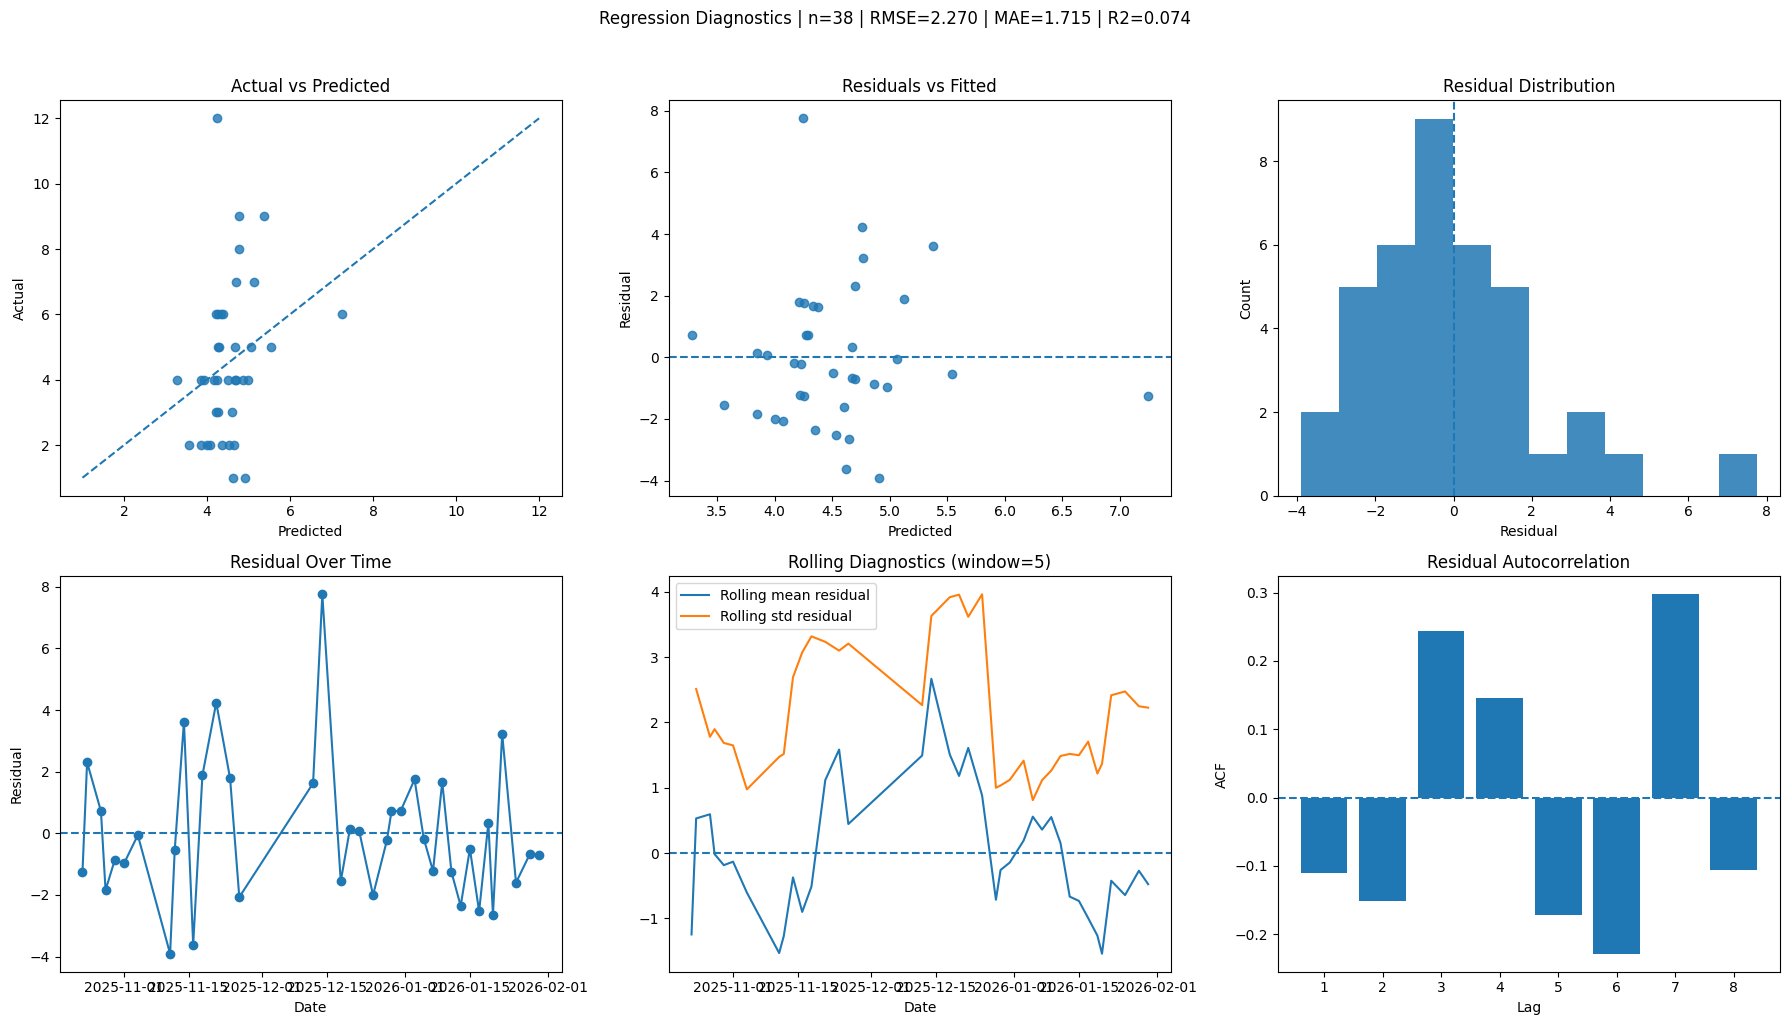

Diagnostics metrics:
- n_obs: 38
- rmse: 2.2704
- mae: 1.7152
- bias_mean_residual: -0.0000
- r2: 0.0737


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_regression_diagnostics(
    model_df: pd.DataFrame,
    y_col: str = "FG3M",
    yhat_col: str = "y_hat",
    date_col: str = "GAME_DATE",
    rolling_window: int = 5,
    lags: int = 8,
):
    """
    Plot core regression diagnostics from a DataFrame that already has actuals and predictions.

    Expected columns:
    - y_col (actual target)
    - yhat_col (model prediction)
    - date_col (time ordering for time-series plots)

    Returns:
    - diagnostics_df (copy with residual columns)
    - metrics (dict)
    """
    df = model_df.copy().sort_values(date_col).reset_index(drop=True)
    df[y_col] = df[y_col].astype(float)
    df[yhat_col] = df[yhat_col].astype(float)
    df["residual"] = df[y_col] - df[yhat_col]
    df["abs_error"] = df["residual"].abs()
    df["sq_error"] = df["residual"] ** 2

    # Metrics
    rmse = float(np.sqrt(df["sq_error"].mean()))
    mae = float(df["abs_error"].mean())
    bias = float(df["residual"].mean())  # positive = underpredicting on average
    ss_res = float(((df[y_col] - df[yhat_col]) ** 2).sum())
    ss_tot = float(((df[y_col] - df[y_col].mean()) ** 2).sum())
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

    metrics = {
        "n_obs": int(len(df)),
        "rmse": rmse,
        "mae": mae,
        "bias_mean_residual": bias,
        "r2": r2,
    }

    # Rolling error diagnostics
    df["rolling_resid_mean"] = df["residual"].rolling(rolling_window, min_periods=1).mean()
    df["rolling_resid_std"] = df["residual"].rolling(rolling_window, min_periods=1).std()

    # Residual autocorrelation by lag
    acf_vals = []
    for lag in range(1, lags + 1):
        acf_vals.append(df["residual"].autocorr(lag=lag))

    # ---- Plots ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

    # 1) Actual vs Predicted
    ax1.scatter(df[yhat_col], df[y_col], alpha=0.8)
    min_v = min(df[y_col].min(), df[yhat_col].min())
    max_v = max(df[y_col].max(), df[yhat_col].max())
    ax1.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    ax1.set_title("Actual vs Predicted")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")

    # 2) Residuals vs Fitted
    ax2.scatter(df[yhat_col], df["residual"], alpha=0.8)
    ax2.axhline(0, linestyle="--")
    ax2.set_title("Residuals vs Fitted")
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Residual")

    # 3) Residual histogram
    ax3.hist(df["residual"], bins=12, alpha=0.85)
    ax3.axvline(0, linestyle="--")
    ax3.set_title("Residual Distribution")
    ax3.set_xlabel("Residual")
    ax3.set_ylabel("Count")

    # 4) Residual over time
    ax4.plot(pd.to_datetime(df[date_col]), df["residual"], marker="o")
    ax4.axhline(0, linestyle="--")
    ax4.set_title("Residual Over Time")
    ax4.set_xlabel("Date")
    ax4.set_ylabel("Residual")

    # 5) Rolling residual mean/std
    x_dates = pd.to_datetime(df[date_col])
    ax5.plot(x_dates, df["rolling_resid_mean"], label="Rolling mean residual")
    ax5.plot(x_dates, df["rolling_resid_std"], label="Rolling std residual")
    ax5.axhline(0, linestyle="--")
    ax5.set_title(f"Rolling Diagnostics (window={rolling_window})")
    ax5.set_xlabel("Date")
    ax5.legend()

    # 6) Residual autocorrelation by lag
    ax6.bar(range(1, lags + 1), acf_vals)
    ax6.axhline(0, linestyle="--")
    ax6.set_title("Residual Autocorrelation")
    ax6.set_xlabel("Lag")
    ax6.set_ylabel("ACF")

    fig.suptitle(
        f"Regression Diagnostics | n={metrics['n_obs']} | RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f}",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()

    print("Diagnostics metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"- {k}: {v:.4f}")
        else:
            print(f"- {k}: {v}")

    return df, metrics


diagnostics_df, diagnostics_metrics = plot_regression_diagnostics(
    model_df=model_df,
    y_col="FG3M",
    yhat_col="y_hat",
    date_col="GAME_DATE",
    rolling_window=5,
    lags=8,
)

You’re not crazy — I checked the full career data, and this is what came back:
- Full career (1064 rows): slope is positive (+0.8147)
- 2025-26 only (38 rows): slope is negative (-1.7006)

So this is mostly a small-sample instability issue, not a fundamental truth about Curry.
What to do so the model behavior matches your expectation:
- Use more training data for coefficient fit
    - Fit on prior seasons + expanding current season history.
    - Score 2025-26 out-of-sample with expanding window.
    - This usually stabilizes sign and magnitude.
- Constrain slope to be non-negative
    - Fit intercept + slope*x with constraint slope >= 0.
    - Then model can never move projections down when running mean goes up.
- Prefer v2-style inputs for signal
    - mean_3pm alone is weak game-to-game.
    - Add attempts/minutes (or matchup/context later) for predictive power.
- Use shrinkage baseline as safety rail
    - Forecast = weighted blend of recent mean and long-run mean.
    - This is monotonic by design and much harder to break in tiny samples.

Recommended next step for your notebook:
1) build expanding-window evaluation for 2025-26,
2) compare unconstrained vs constrained-positive slope,
3) plot coefficient path over dates.

If you want, I’ll give you the exact notebook cells for that next.


In [24]:
# Cell 1 — Expanding-window setup (2025-26 scoring, full-history training)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build modeling table from full Curry history
df = (
    curry_games_df.copy()
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
df["FG3M"] = df["FG3M"].astype(float)

# Feature: lagged running mean of last 100 games (uses only prior games)
df["x_last100_mean_3pm"] = (
    df["FG3M"]
    .rolling(window=100, min_periods=1)
    .mean()
    .shift(1)
)

# We score only 2025-26 games, but train on all prior career rows
df["is_test_2025_26"] = df["SEASON_STR"] == "2025-26"

min_train_games = 25  # guardrail for early, unstable fits
print("total rows:", len(df))
print("test rows:", int(df["is_test_2025_26"].sum()))

total rows: 1065
test rows: 39


In [25]:
# Cell 2 — Walk-forward fit: unconstrained vs constrained-positive slope

def fit_one_feature_models(train_x: np.ndarray, train_y: np.ndarray):
    """
    Fit two one-feature models:
    1) unconstrained OLS
    2) constrained slope >= 0
    """
    X = np.column_stack([np.ones(len(train_x)), train_x])
    b0_ols, b1_ols = np.linalg.lstsq(X, train_y, rcond=None)[0]

    # Constrained solution for slope >= 0 in 1D:
    # - if OLS slope is non-negative, keep OLS
    # - else best boundary solution is slope=0, intercept=mean(y)
    if b1_ols >= 0:
        b0_pos, b1_pos = b0_ols, b1_ols
    else:
        b0_pos, b1_pos = float(train_y.mean()), 0.0

    return float(b0_ols), float(b1_ols), float(b0_pos), float(b1_pos)


rows = []

for i in range(len(df)):
    row = df.iloc[i]

    if not row["is_test_2025_26"]:
        continue
    if pd.isna(row["x_last100_mean_3pm"]):
        continue

    train = df.iloc[:i].dropna(subset=["x_last100_mean_3pm"]).copy()
    if len(train) < min_train_games:
        continue

    x_train = train["x_last100_mean_3pm"].to_numpy(dtype=float)
    y_train = train["FG3M"].to_numpy(dtype=float)

    b0_ols, b1_ols, b0_pos, b1_pos = fit_one_feature_models(x_train, y_train)

    x_t = float(row["x_last100_mean_3pm"])
    y_t = float(row["FG3M"])

    yhat_ols = b0_ols + b1_ols * x_t
    yhat_pos = b0_pos + b1_pos * x_t

    rows.append(
        {
            "GAME_DATE": row["GAME_DATE"],
            "SEASON_STR": row["SEASON_STR"],
            "Game_ID": row["Game_ID"],
            "FG3M": y_t,
            "x_last100_mean_3pm": x_t,
            "yhat_ols": yhat_ols,
            "yhat_pos_slope": yhat_pos,
            "b0_ols": b0_ols,
            "b1_ols": b1_ols,
            "b0_pos": b0_pos,
            "b1_pos": b1_pos,
            "n_train": len(train),
        }
    )

wf_df = pd.DataFrame(rows).sort_values("GAME_DATE").reset_index(drop=True)

# Errors
wf_df["resid_ols"] = wf_df["FG3M"] - wf_df["yhat_ols"]
wf_df["resid_pos"] = wf_df["FG3M"] - wf_df["yhat_pos_slope"]


def calc_metrics(actual: pd.Series, pred: pd.Series):
    actual = actual.astype(float).to_numpy()
    pred = pred.astype(float).to_numpy()
    rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    mae = float(np.mean(np.abs(actual - pred)))
    bias = float(np.mean(actual - pred))
    ss_res = float(np.sum((actual - pred) ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "bias": bias, "r2": r2, "n": len(actual)}


m_ols = calc_metrics(wf_df["FG3M"], wf_df["yhat_ols"])
m_pos = calc_metrics(wf_df["FG3M"], wf_df["yhat_pos_slope"])

print("Walk-forward results (2025-26)")
print("OLS unconstrained:", m_ols)
print("Constrained slope>=0:", m_pos)

wf_df.tail(10)

Walk-forward results (2025-26)
OLS unconstrained: {'rmse': 2.3512895679039576, 'mae': 1.8263768190537364, 'bias': -0.048902494952532405, 'r2': -0.008750451472622878, 'n': 39}
Constrained slope>=0: {'rmse': 2.3512895679039576, 'mae': 1.8263768190537364, 'bias': -0.048902494952532405, 'r2': -0.008750451472622878, 'n': 39}


,GAME_DATE,SEASON_STR,Game_ID,FG3M,x_last100_mean_3pm,yhat_ols,yhat_pos_slope,b0_ols,b1_ols,b0_pos,b1_pos,n_train,resid_ols,resid_pos
29,2026-01-11,2025-26,22500556,3.0,4.56,4.586536,4.586536,0.851966,0.818985,0.851966,0.818985,1054,-1.586536,-1.586536
30,2026-01-13,2025-26,22500570,2.0,4.52,4.551689,4.551689,0.853655,0.818149,0.853655,0.818149,1055,-2.551689,-2.551689
31,2026-01-15,2025-26,22500584,4.0,4.51,4.540218,4.540218,0.856089,0.816880,0.856089,0.816880,1056,-0.540218,-0.540218
32,2026-01-17,2025-26,22500599,2.0,4.51,4.539525,4.539525,0.856589,0.816616,0.856589,0.816616,1057,-2.539525,-2.539525
33,2026-01-19,2025-26,22500612,5.0,4.49,4.519965,4.519965,0.858937,0.815374,0.858937,0.815374,1058,0.480035,0.480035
34,2026-01-20,2025-26,22500618,2.0,4.50,4.528726,4.528726,0.858520,0.815601,0.858520,0.815601,1059,-2.528726,-2.528726
35,2026-01-22,2025-26,22500630,8.0,4.48,4.509232,4.509232,0.860783,0.814386,0.860783,0.814386,1060,3.490768,3.490768
36,2026-01-25,2025-26,22500644,3.0,4.55,4.570707,4.570707,0.857853,0.816012,0.857853,0.816012,1061,-1.570707,-1.570707
37,2026-01-28,2025-26,22500678,4.0,4.51,4.536034,4.536034,0.859468,0.815203,0.859468,0.815203,1062,-0.536034,-0.536034
38,2026-01-30,2025-26,22500696,4.0,4.50,4.527203,4.527203,0.859961,0.814943,0.859961,0.814943,1063,-0.527203,-0.527203


In [26]:
# basically the same ...

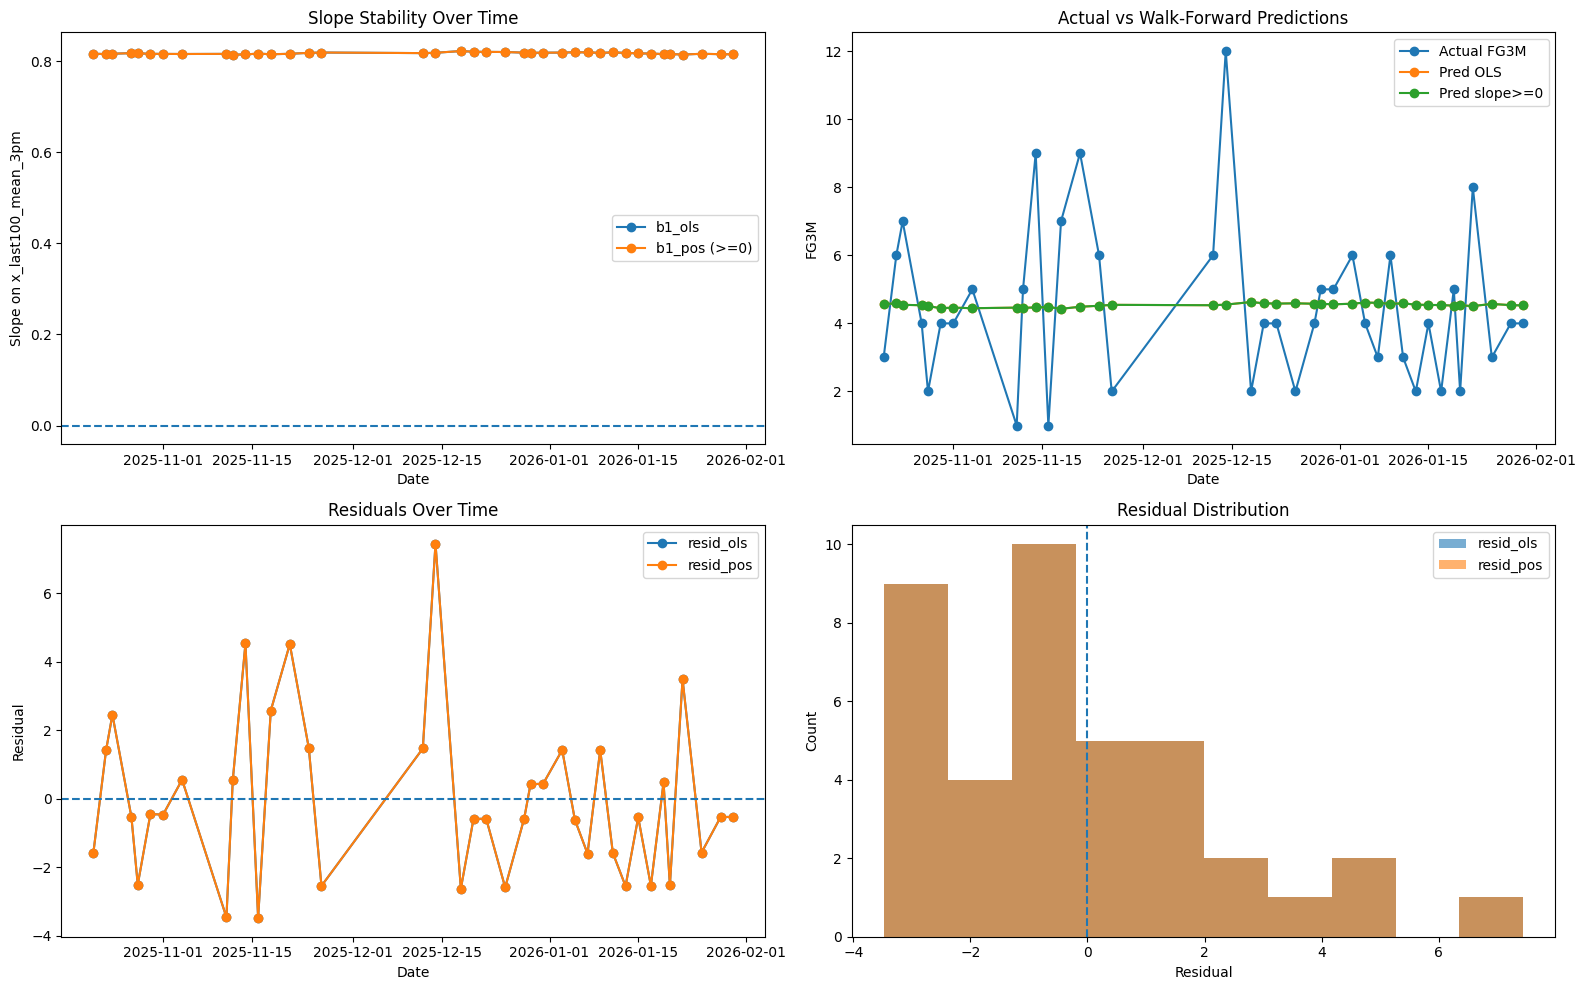

Latest coefficients:


,GAME_DATE,n_train,b0_ols,b1_ols,b0_pos,b1_pos
29,2026-01-11,1054,0.851966,0.818985,0.851966,0.818985
30,2026-01-13,1055,0.853655,0.818149,0.853655,0.818149
31,2026-01-15,1056,0.856089,0.816880,0.856089,0.816880
32,2026-01-17,1057,0.856589,0.816616,0.856589,0.816616
33,2026-01-19,1058,0.858937,0.815374,0.858937,0.815374
34,2026-01-20,1059,0.858520,0.815601,0.858520,0.815601
35,2026-01-22,1060,0.860783,0.814386,0.860783,0.814386
36,2026-01-25,1061,0.857853,0.816012,0.857853,0.816012
37,2026-01-28,1062,0.859468,0.815203,0.859468,0.815203
38,2026-01-30,1063,0.859961,0.814943,0.859961,0.814943


In [27]:
# Cell 3 — Coefficient stability + residual diagnostics plots

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# 1) Coefficient path over test dates
ax1.plot(wf_df["GAME_DATE"], wf_df["b1_ols"], marker="o", label="b1_ols")
ax1.plot(wf_df["GAME_DATE"], wf_df["b1_pos"], marker="o", label="b1_pos (>=0)")
ax1.axhline(0, linestyle="--")
ax1.set_title("Slope Stability Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Slope on x_last100_mean_3pm")
ax1.legend()

# 2) Predictions vs actuals
ax2.plot(wf_df["GAME_DATE"], wf_df["FG3M"], marker="o", label="Actual FG3M")
ax2.plot(wf_df["GAME_DATE"], wf_df["yhat_ols"], marker="o", label="Pred OLS")
ax2.plot(wf_df["GAME_DATE"], wf_df["yhat_pos_slope"], marker="o", label="Pred slope>=0")
ax2.set_title("Actual vs Walk-Forward Predictions")
ax2.set_xlabel("Date")
ax2.set_ylabel("FG3M")
ax2.legend()

# 3) Residuals over time
ax3.plot(wf_df["GAME_DATE"], wf_df["resid_ols"], marker="o", label="resid_ols")
ax3.plot(wf_df["GAME_DATE"], wf_df["resid_pos"], marker="o", label="resid_pos")
ax3.axhline(0, linestyle="--")
ax3.set_title("Residuals Over Time")
ax3.set_xlabel("Date")
ax3.set_ylabel("Residual")
ax3.legend()

# 4) Residual distributions
ax4.hist(wf_df["resid_ols"], bins=10, alpha=0.6, label="resid_ols")
ax4.hist(wf_df["resid_pos"], bins=10, alpha=0.6, label="resid_pos")
ax4.axvline(0, linestyle="--")
ax4.set_title("Residual Distribution")
ax4.set_xlabel("Residual")
ax4.set_ylabel("Count")
ax4.legend()

fig.tight_layout()
plt.show()

print("Latest coefficients:")
display(
    wf_df[
        ["GAME_DATE", "n_train", "b0_ols", "b1_ols", "b0_pos", "b1_pos"]
    ].tail(10)
)

takeaway: curry is hard to model, let's add some more players into this 

next: top 50 by 3pt fgm in 2025-26

In [31]:
import os, subprocess

# pull creds from your AWS CLI config
os.environ["AWS_ACCESS_KEY_ID"] = subprocess.check_output(
    ["aws", "configure", "get", "aws_access_key_id"], text=True
).strip()

os.environ["AWS_SECRET_ACCESS_KEY"] = subprocess.check_output(
    ["aws", "configure", "get", "aws_secret_access_key"], text=True
).strip()

os.environ["AWS_DEFAULT_REGION"] = "us-east-2"
# Optional: some libs look for AWS_REGION too
os.environ["AWS_REGION"] = "us-east-2"

for k in ["AWS_ACCESS_KEY_ID","AWS_SECRET_ACCESS_KEY","AWS_DEFAULT_REGION","AWS_REGION","AWS_SESSION_TOKEN"]:
    print(k, "=>", "SET" if k in os.environ else "MISSING")

AWS_ACCESS_KEY_ID => SET
AWS_SECRET_ACCESS_KEY => SET
AWS_DEFAULT_REGION => SET
AWS_REGION => SET
AWS_SESSION_TOKEN => MISSING


In [32]:
# Cell 1 — Load 2025-26 player game logs + top 50 shooters

import os
import duckdb
import pandas as pd

SEASON = "2025-26"
MIN_GAMES = 25

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET s3_region='us-east-2'")
con.execute(f"SET s3_access_key_id='{os.environ['AWS_ACCESS_KEY_ID']}'")
con.execute(f"SET s3_secret_access_key='{os.environ['AWS_SECRET_ACCESS_KEY']}'")

# optional if your session uses temporary creds
if "AWS_SESSION_TOKEN" in os.environ:
    con.execute(f"SET s3_session_token='{os.environ['AWS_SESSION_TOKEN']}'")

logs = con.execute(f"""
SELECT
  PLAYER_ID,
  PLAYER_NAME,
  GAME_ID,
  GAME_DATE,
  FG3M,
  FG3A,
  MIN
FROM read_csv_auto('s3://nba-api-mt/player_game_logs/{SEASON}/*.csv', union_by_name=true)
""").fetchdf()

logs["GAME_DATE"] = pd.to_datetime(logs["GAME_DATE"])
logs["FG3M"] = logs["FG3M"].astype(float)
logs["FG3A"] = logs["FG3A"].astype(float)
logs["MIN"] = logs["MIN"].astype(float)

player_summary = (
    logs.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(
        games=("GAME_ID", "count"),
        avg_3pm=("FG3M", "mean"),
        avg_3pa=("FG3A", "mean"),
        avg_min=("MIN", "mean"),
    )
    .query("games >= @MIN_GAMES")
    .sort_values("avg_3pm", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

top50_ids = set(player_summary["PLAYER_ID"].tolist())
top50_logs = logs[logs["PLAYER_ID"].isin(top50_ids)].copy()

print("rows in logs:", len(logs))
print("top50 players:", len(player_summary))
player_summary.head(10)

rows in logs: 20102
top50 players: 50


,PLAYER_ID,PLAYER_NAME,games,avg_3pm,avg_3pa,avg_min
0,201939,Stephen Curry,39,4.487179,11.487179,31.325085
1,1629029,Luka Dončić,44,3.659091,10.295455,35.510265
2,1630163,LaMelo Ball,48,3.500000,9.541667,27.755313
3,1628378,Donovan Mitchell,54,3.500000,9.425926,33.494969
4,1629008,Michael Porter Jr.,44,3.477273,9.386364,32.865303
5,1642851,Kon Knueppel,57,3.473684,7.982456,32.114708
6,1630241,Sam Merrill,34,3.470588,7.323529,25.310196
7,1630162,Anthony Edwards,48,3.395833,8.479167,35.499514
8,1628960,Grayson Allen,36,3.361111,9.194444,30.349630
9,1630178,Tyrese Maxey,55,3.345455,8.872727,38.511212


In [35]:
import sys

SRC_DIR = "/Users/thomasmyles/dev/betting/src"
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from player_name_utils import normalize_player_name

# Normalize names first so Luka Dončić + Luka Doncic collapse to one player
player_summary["PLAYER_NAME"] = player_summary["PLAYER_NAME"].apply(normalize_player_name)
display(player_summary.head(3))

top50_logs["PLAYER_NAME"] = top50_logs["PLAYER_NAME"].apply(normalize_player_name)
display(top50_logs.head(3))

,PLAYER_ID,PLAYER_NAME,games,avg_3pm,avg_3pa,avg_min
0,201939,Stephen Curry,39,4.487179,11.487179,31.325085
1,1629029,Luka Doncic,44,3.659091,10.295455,35.510265
2,1630163,Lamelo Ball,48,3.500000,9.541667,27.755313


,PLAYER_ID,PLAYER_NAME,GAME_ID,GAME_DATE,FG3M,FG3A,MIN
0,1629029,Luka Doncic,0022500002,2025-10-21,2.0,10.0,40.983333
3,1630559,Austin Reaves,0022500002,2025-10-21,1.0,5.0,36.333333
5,201939,Stephen Curry,0022500002,2025-10-21,3.0,9.0,32.066667


In [36]:
# Cell 2 — Walk-forward model functions (expanding window)

def fit_ols(train_X: np.ndarray, train_y: np.ndarray) -> np.ndarray:
    X = np.column_stack([np.ones(len(train_X)), train_X])
    beta = np.linalg.lstsq(X, train_y, rcond=None)[0]
    return beta  # [intercept, coefs...]

def predict_ols(beta: np.ndarray, x_row: np.ndarray) -> float:
    return float(beta[0] + np.dot(x_row, beta[1:]))

def player_walkforward_eval(player_df: pd.DataFrame, min_train_games: int = 20) -> dict:
    """
    Compare:
    - naive baseline: yhat = lag_mean_fg3m
    - v1 OLS: y ~ lag_mean_fg3m
    - v2 OLS: y ~ lag_mean_fg3m + lag_mean_fg3a + lag_mean_min
    """
    df = player_df.sort_values("GAME_DATE").reset_index(drop=True).copy()

    # Lagged expanding features (only past info)
    df["lag_mean_fg3m"] = df["FG3M"].expanding(min_periods=1).mean().shift(1)
    df["lag_mean_fg3a"] = df["FG3A"].expanding(min_periods=1).mean().shift(1)
    df["lag_mean_min"] = df["MIN"].expanding(min_periods=1).mean().shift(1)

    df = df.dropna(subset=["lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]).copy()
    if len(df) <= min_train_games:
        return {
            "n_scored": 0,
            "rmse_naive": np.nan,
            "rmse_v1": np.nan,
            "rmse_v2": np.nan,
            "mae_naive": np.nan,
            "mae_v1": np.nan,
            "mae_v2": np.nan,
            "r2_v1": np.nan,
            "r2_v2": np.nan,
            "v1_vs_naive_rmse_gain": np.nan,
            "v2_vs_naive_rmse_gain": np.nan,
            "v2_vs_v1_rmse_gain": np.nan,
        }

    y_true = []
    yhat_naive = []
    yhat_v1 = []
    yhat_v2 = []

    for i in range(min_train_games, len(df)):
        train = df.iloc[:i]
        row = df.iloc[i]

        y_train = train["FG3M"].to_numpy(dtype=float)

        # naive
        pred_naive = float(row["lag_mean_fg3m"])

        # v1
        X1_train = train[["lag_mean_fg3m"]].to_numpy(dtype=float)
        beta1 = fit_ols(X1_train, y_train)
        pred_v1 = predict_ols(beta1, np.array([row["lag_mean_fg3m"]], dtype=float))

        # v2
        X3_train = train[["lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]].to_numpy(dtype=float)
        beta3 = fit_ols(X3_train, y_train)
        pred_v2 = predict_ols(
            beta3,
            np.array([row["lag_mean_fg3m"], row["lag_mean_fg3a"], row["lag_mean_min"]], dtype=float),
        )

        y_true.append(float(row["FG3M"]))
        yhat_naive.append(pred_naive)
        yhat_v1.append(pred_v1)
        yhat_v2.append(pred_v2)

    y_true = np.array(y_true, dtype=float)
    yhat_naive = np.array(yhat_naive, dtype=float)
    yhat_v1 = np.array(yhat_v1, dtype=float)
    yhat_v2 = np.array(yhat_v2, dtype=float)

    def rmse(a, b):
        return float(np.sqrt(np.mean((a - b) ** 2)))

    def mae(a, b):
        return float(np.mean(np.abs(a - b)))

    rmse_naive = rmse(y_true, yhat_naive)
    rmse_v1 = rmse(y_true, yhat_v1)
    rmse_v2 = rmse(y_true, yhat_v2)

    mae_naive = mae(y_true, yhat_naive)
    mae_v1 = mae(y_true, yhat_v1)
    mae_v2 = mae(y_true, yhat_v2)

    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2_v1 = 1.0 - float(np.sum((y_true - yhat_v1) ** 2)) / ss_tot if ss_tot > 0 else np.nan
    r2_v2 = 1.0 - float(np.sum((y_true - yhat_v2) ** 2)) / ss_tot if ss_tot > 0 else np.nan

    return {
        "n_scored": int(len(y_true)),
        "rmse_naive": rmse_naive,
        "rmse_v1": rmse_v1,
        "rmse_v2": rmse_v2,
        "mae_naive": mae_naive,
        "mae_v1": mae_v1,
        "mae_v2": mae_v2,
        "r2_v1": r2_v1,
        "r2_v2": r2_v2,
        "v1_vs_naive_rmse_gain": rmse_naive - rmse_v1,
        "v2_vs_naive_rmse_gain": rmse_naive - rmse_v2,
        "v2_vs_v1_rmse_gain": rmse_v1 - rmse_v2,
    }

In [37]:
# Cell 3 — Run across top 50 and rank predictability

rows = []

for _, p in player_summary.iterrows():
    pid = p["PLAYER_ID"]
    pname = p["PLAYER_NAME"]
    pdf = top50_logs[top50_logs["PLAYER_ID"] == pid].copy()

    metrics = player_walkforward_eval(pdf, min_train_games=20)

    rows.append(
        {
            "PLAYER_ID": pid,
            "PLAYER_NAME": pname,
            "games": int(p["games"]),
            "avg_3pm": float(p["avg_3pm"]),
            "avg_3pa": float(p["avg_3pa"]),
            "avg_min": float(p["avg_min"]),
            **metrics,
        }
    )

results = pd.DataFrame(rows)

# Better if lower RMSE, higher R2, and positive gain values
results_ranked = results.sort_values(
    ["rmse_v2", "r2_v2", "v2_vs_v1_rmse_gain"],
    ascending=[True, False, False],
).reset_index(drop=True)

print("Players where v2 beats v1 on RMSE:", int((results["v2_vs_v1_rmse_gain"] > 0).sum()), "/", len(results))
print("Players where v2 beats naive on RMSE:", int((results["v2_vs_naive_rmse_gain"] > 0).sum()), "/", len(results))

results_ranked[
    [
        "PLAYER_NAME", "games", "avg_3pm", "n_scored",
        "rmse_naive", "rmse_v1", "rmse_v2",
        "r2_v1", "r2_v2",
        "v1_vs_naive_rmse_gain", "v2_vs_naive_rmse_gain", "v2_vs_v1_rmse_gain",
    ]
].head(20)

Players where v2 beats v1 on RMSE: 14 / 50
Players where v2 beats naive on RMSE: 13 / 50


,PLAYER_NAME,games,avg_3pm,n_scored,rmse_naive,rmse_v1,rmse_v2,r2_v1,r2_v2,v1_vs_naive_rmse_gain,v2_vs_naive_rmse_gain,v2_vs_v1_rmse_gain
0,Zach Lavine,39,2.538462,18,1.277971,1.386099,1.182846,-0.377195,-0.002913,-0.108129,0.095124,0.203253
1,Lauri Markkanen,42,2.738095,21,1.113205,1.061956,1.201497,-0.120131,-0.433841,0.051248,-0.088292,-0.139541
2,Reed Sheppard,56,2.428571,35,1.575802,1.573964,1.517362,-0.033640,0.039366,0.001839,0.058441,0.056602
3,Brandon Miller,41,3.000000,20,1.566115,1.580394,1.537913,-0.073102,-0.016187,-0.014279,0.028202,0.042481
4,Donte Divincenzo,58,3.051724,37,1.578077,1.574220,1.603742,-0.030562,-0.069578,0.003857,-0.025665,-0.029522
5,Nickeil Alexander-Walker,57,3.035088,36,1.586107,1.607898,1.612487,-0.086798,-0.093009,-0.021792,-0.026380,-0.004589
6,Toumani Camara,58,2.586207,37,1.639544,1.663702,1.654004,-0.065597,-0.053209,-0.024158,-0.014460,0.009699
7,Moses Moody,55,2.436364,34,1.669070,1.744604,1.668434,-0.121955,-0.026125,-0.075534,0.000636,0.076169
8,Ryan Rollins,53,2.509434,32,1.604416,1.607968,1.673889,-0.037873,-0.124716,-0.003552,-0.069473,-0.065921
9,James Harden,50,3.020000,29,1.414787,1.508146,1.694389,-0.602058,-1.022171,-0.093358,-0.279602,-0.186243


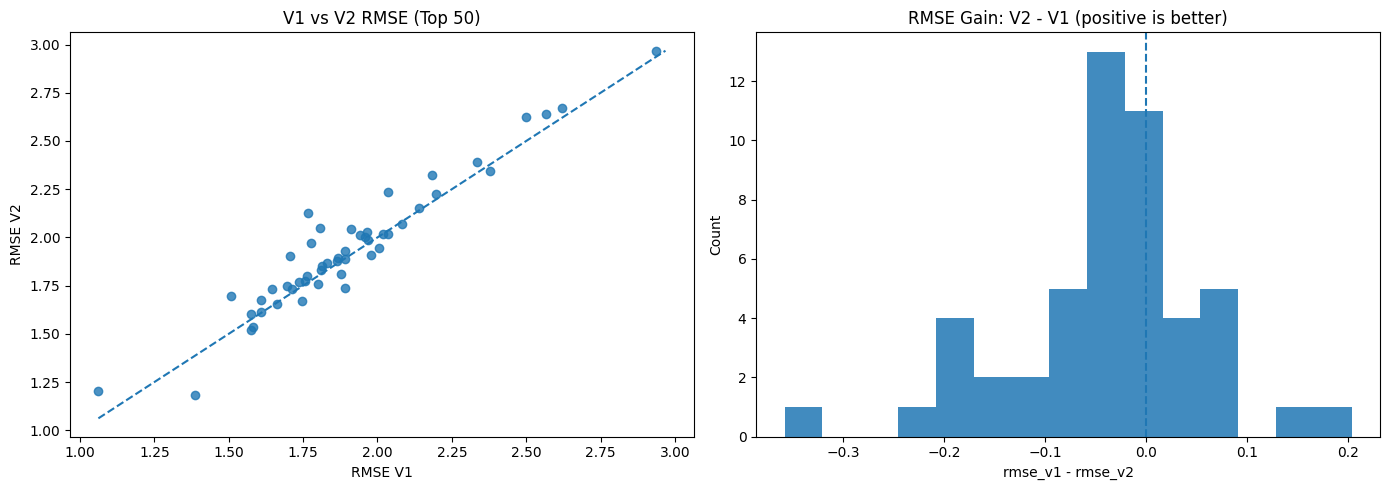

In [39]:
# Cell 4 — Quick plots to see if “better modeling” exists

import matplotlib.pyplot as plt

plot_df = results.dropna(subset=["rmse_v2", "v2_vs_v1_rmse_gain"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].scatter(plot_df["rmse_v1"], plot_df["rmse_v2"], alpha=0.8)
mn = min(plot_df["rmse_v1"].min(), plot_df["rmse_v2"].min())
mx = max(plot_df["rmse_v1"].max(), plot_df["rmse_v2"].max())
axes[0].plot([mn, mx], [mn, mx], linestyle="--")
axes[0].set_title("V1 vs V2 RMSE (Top 50)")
axes[0].set_xlabel("RMSE V1")
axes[0].set_ylabel("RMSE V2")

# Gain distribution
axes[1].hist(plot_df["v2_vs_v1_rmse_gain"], bins=15, alpha=0.85)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("RMSE Gain: V2 - V1 (positive is better)")
axes[1].set_xlabel("rmse_v1 - rmse_v2")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

These outputs are super useful. Main read:
- V2 is not consistently better than V1 or naive in this setup.
- The gain distribution looks centered near ~0 with slight negative tilt, so v2 adds noise more often than signal.
- Many r2 values are negative (for both v1/v2), meaning both regressions often underperform a simple mean-style baseline.
- You do have some wins (for example Zach LaVine, Kawhi, Kon), but they’re not broad enough to justify v2 as-is.

Why this is happening (most likely):
- Too little per-player data for 3-parameter walk-forward fits.
- Inputs are strongly related (lag_mean_fg3m, lag_mean_fg3a, lag_mean_min) so coefficients can become unstable.
- 3PM game-to-game is noisy and partly matchup/context driven; current features are mostly player-form only.

What I’d do next (high ROI):
- Keep your walk-forward eval, but add regularized v2 (Ridge) and compare vs OLS.
- Add a single robust feature: expected_attempts = lag_mean_fg3a and model conversion separately (or just use attempts-only first).
- Run a pooled model across players (with player fixed effect or player baseline) instead of one model per player.
- Compare against two simple baselines:
    - lag mean 3PM,
    - lag mean of last 10 games (not expanding all history).

If you want, I can give you a drop-in next cell that runs Ridge walk-forward for the same top-50 table so you can see immediately whether stability improves.

In [40]:
# Use these notebook cells to build a pooled (all-player) model for top-50 shooters and compare v1 vs v2.

# Cell 1: build top-50 dataset (2025-26)

import os
import duckdb
import numpy as np
import pandas as pd

SEASON = "2025-26"
MIN_GAMES = 25
TOP_N = 50

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET s3_region='us-east-2'")
con.execute(f"SET s3_access_key_id='{os.environ['AWS_ACCESS_KEY_ID']}'")
con.execute(f"SET s3_secret_access_key='{os.environ['AWS_SECRET_ACCESS_KEY']}'")
if "AWS_SESSION_TOKEN" in os.environ:
    con.execute(f"SET s3_session_token='{os.environ['AWS_SESSION_TOKEN']}'")

logs = con.execute(f"""
SELECT
  PLAYER_ID,
  PLAYER_NAME,
  GAME_ID,
  GAME_DATE,
  FG3M,
  FG3A,
  MIN
FROM read_csv_auto('s3://nba-api-mt/player_game_logs/{SEASON}/*.csv', union_by_name=true)
""").fetchdf()

logs["GAME_DATE"] = pd.to_datetime(logs["GAME_DATE"])
logs["FG3M"] = logs["FG3M"].astype(float)
logs["FG3A"] = logs["FG3A"].astype(float)
logs["MIN"] = logs["MIN"].astype(float)

player_summary = (
    logs.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(
        games=("GAME_ID", "count"),
        avg_3pm=("FG3M", "mean"),
    )
    .query("games >= @MIN_GAMES")
    .sort_values("avg_3pm", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_ids = set(player_summary["PLAYER_ID"].tolist())
df = logs[logs["PLAYER_ID"].isin(top_ids)].copy()

print("players:", len(player_summary), "rows:", len(df))
player_summary.head(10)

players: 50 rows: 2429


,PLAYER_ID,PLAYER_NAME,games,avg_3pm
0,201939,Stephen Curry,39,4.487179
1,1629029,Luka Dončić,44,3.659091
2,1630163,LaMelo Ball,48,3.500000
3,1628378,Donovan Mitchell,54,3.500000
4,1629008,Michael Porter Jr.,44,3.477273
5,1642851,Kon Knueppel,57,3.473684
6,1630241,Sam Merrill,34,3.470588
7,1630162,Anthony Edwards,48,3.395833
8,1628960,Grayson Allen,36,3.361111
9,1630178,Tyrese Maxey,55,3.345455


In [41]:
# Normalize names first so Luka Dončić + Luka Doncic collapse to one player
player_summary["PLAYER_NAME"] = player_summary["PLAYER_NAME"].apply(normalize_player_name)
top50_logs["PLAYER_NAME"] = top50_logs["PLAYER_NAME"].apply(normalize_player_name)

In [42]:
df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

g = df.groupby("PLAYER_ID", group_keys=False)

# v1 feature
df["lag_mean_fg3m"] = g["FG3M"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))

# v2 adds these
df["lag_mean_fg3a"] = g["FG3A"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))
df["lag_mean_min"] = g["MIN"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))

# drop first row per player where lagged features are NaN
model_df = df.dropna(subset=["lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]).copy()

print("model rows:", len(model_df))
model_df[["PLAYER_NAME", "GAME_DATE", "FG3M", "lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]].head(10)

model rows: 2379


,PLAYER_NAME,GAME_DATE,FG3M,lag_mean_fg3m,lag_mean_fg3a,lag_mean_min
1,Kevin Durant,2025-10-24,3.0,0.000000,4.000000,47.050000
2,Kevin Durant,2025-10-27,0.0,1.500000,3.500000,41.926667
3,Kevin Durant,2025-10-29,4.0,1.000000,3.666667,36.216667
4,Kevin Durant,2025-11-01,2.0,1.750000,4.750000,36.350000
5,Kevin Durant,2025-11-03,2.0,1.800000,4.400000,34.991000
6,Kevin Durant,2025-11-05,1.0,1.833333,5.000000,35.558333
7,Kevin Durant,2025-11-07,1.0,1.714286,4.571429,35.400000
8,Kevin Durant,2025-11-09,2.0,1.625000,4.250000,35.543750
9,Kevin Durant,2025-11-12,2.0,1.666667,4.000000,35.744444
10,Kevin Durant,2025-11-14,3.0,1.700000,4.100000,35.256167


In [43]:
# Cell 3: train/test split per player (time-aware)

def mark_train_test_per_player(player_df: pd.DataFrame, train_frac: float = 0.7, min_train: int = 20) -> pd.DataFrame:
    player_df = player_df.sort_values("GAME_DATE").copy()
    n = len(player_df)
    split_idx = max(min_train, int(n * train_frac))
    split_idx = min(split_idx, n - 1)  # keep at least 1 test row
    player_df["is_train"] = False
    player_df.iloc[:split_idx, player_df.columns.get_loc("is_train")] = True
    return player_df

split_df = (
    model_df.groupby("PLAYER_ID", group_keys=False)
    .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)
    .reset_index(drop=True)
)

train_df = split_df[split_df["is_train"]].copy()
test_df = split_df[~split_df["is_train"]].copy()

print("train rows:", len(train_df), "test rows:", len(test_df))

train rows: 1648 test rows: 731


/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_84124/2037645779.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)


In [44]:
# Cell 4: pooled model fit/predict helpers (with player fixed effects)

def build_design_matrix(
    frame: pd.DataFrame,
    feature_cols: list[str],
    player_levels: list[int],
    include_player_effects: bool = True,
) -> np.ndarray:
    x_main = frame[feature_cols].to_numpy(dtype=float)
    parts = [np.ones((len(frame), 1), dtype=float), x_main]

    if include_player_effects:
        # one-hot player dummies (drop first to avoid exact collinearity with intercept)
        cats = pd.Categorical(frame["PLAYER_ID"], categories=player_levels)
        dummies = pd.get_dummies(cats, drop_first=True).to_numpy(dtype=float)
        parts.append(dummies)

    return np.hstack(parts)

def fit_ols_and_predict(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    feature_cols: list[str],
    include_player_effects: bool = True,
):
    player_levels = sorted(train_frame["PLAYER_ID"].unique().tolist())
    X_train = build_design_matrix(train_frame, feature_cols, player_levels, include_player_effects)
    y_train = train_frame["FG3M"].to_numpy(dtype=float)

    beta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = build_design_matrix(test_frame, feature_cols, player_levels, include_player_effects)
    y_hat = X_test @ beta
    y_hat = np.clip(y_hat, 0.0, None)
    return beta, y_hat

def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "r2": r2}

In [45]:
# Cell 5: fit v1 and v2, compare performance

# v1: one feature
v1_features = ["lag_mean_fg3m"]

# v2: three features
v2_features = ["lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]

# Fit + predict
_, yhat_v1 = fit_ols_and_predict(train_df, test_df, v1_features, include_player_effects=True)
_, yhat_v2 = fit_ols_and_predict(train_df, test_df, v2_features, include_player_effects=True)

y_test = test_df["FG3M"].to_numpy(dtype=float)

m_v1 = metrics(y_test, yhat_v1)
m_v2 = metrics(y_test, yhat_v2)

print("Pooled test metrics")
print("v1:", m_v1)
print("v2:", m_v2)
print("v2_rmse_gain_vs_v1:", round(m_v1["rmse"] - m_v2["rmse"], 4))

results_df = test_df[["PLAYER_ID", "PLAYER_NAME", "GAME_DATE", "FG3M"]].copy()
results_df["yhat_v1"] = yhat_v1
results_df["yhat_v2"] = yhat_v2
results_df["abs_err_v1"] = (results_df["FG3M"] - results_df["yhat_v1"]).abs()
results_df["abs_err_v2"] = (results_df["FG3M"] - results_df["yhat_v2"]).abs()

results_df.head(15)

Pooled test metrics
v1: {'rmse': 1.9318080640103537, 'mae': 1.5441271100239617, 'r2': -0.0366230060001973}
v2: {'rmse': 1.9309859757623493, 'mae': 1.5434183014302683, 'r2': -0.0357409160253348}
v2_rmse_gain_vs_v1: 0.0008


,PLAYER_ID,PLAYER_NAME,GAME_DATE,FG3M,yhat_v1,yhat_v2,abs_err_v1,abs_err_v2
36,201142,Kevin Durant,2026-01-18,1.0,2.207918,2.174059,1.207918,1.174059
37,201142,Kevin Durant,2026-01-20,2.0,2.213621,2.174578,0.213621,0.174578
38,201142,Kevin Durant,2026-01-22,5.0,2.214463,2.179666,2.785537,2.820334
39,201142,Kevin Durant,2026-01-23,5.0,2.201899,2.170747,2.798101,2.829253
40,201142,Kevin Durant,2026-01-26,4.0,2.189948,2.155661,1.810052,1.844339
41,201142,Kevin Durant,2026-01-28,2.0,2.182808,2.145217,0.182808,0.145217
42,201142,Kevin Durant,2026-01-29,3.0,2.184288,2.148465,0.815712,0.851535
43,201142,Kevin Durant,2026-01-31,1.0,2.181651,2.141680,1.181651,1.141680
44,201142,Kevin Durant,2026-02-04,0.0,2.187050,2.149435,2.187050,2.149435
45,201142,Kevin Durant,2026-02-05,3.0,2.196089,2.156681,0.803911,0.843319


In [47]:
# Cell 6: per-player comparison table (who v2 helps/hurts)

player_compare = (
    results_df.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(
        n_test=("FG3M", "count"),
        mae_v1=("abs_err_v1", "mean"),
        mae_v2=("abs_err_v2", "mean"),
    )
)

player_compare["mae_gain_v2_vs_v1"] = player_compare["mae_v1"] - player_compare["mae_v2"]
player_compare = player_compare.sort_values("mae_gain_v2_vs_v1", ascending=False).reset_index(drop=True)

print("players where v2 better (mae):", int((player_compare["mae_gain_v2_vs_v1"] > 0).sum()), "/", len(player_compare))
player_compare.head(50)

players where v2 better (mae): 29 / 50


,PLAYER_ID,PLAYER_NAME,n_test,mae_v1,mae_v2,mae_gain_v2_vs_v1
0,1630170,Devin Vassell,13,1.682623,1.651797,0.030826
1,1641706,Brandon Miller,12,1.360347,1.331202,0.029145
2,202695,Kawhi Leonard,13,1.321150,1.300413,0.020736
3,1631221,Collin Gillespie,17,1.176638,1.156817,0.019821
4,1630559,Austin Reaves,9,1.823826,1.807561,0.016265
5,1626181,Norman Powell,14,1.365567,1.350757,0.014810
6,1630577,Julian Champagnie,17,1.572739,1.558406,0.014333
7,1630541,Moses Moody,17,1.730927,1.719369,0.011558
8,1630178,Tyrese Maxey,17,1.565451,1.554476,0.010975
9,1629673,Jordan Poole,9,1.491434,1.481894,0.009540


yes: in current form, these mean models are weak for nightly 3PM point prediction.
Most useful pivot now:
Stop optimizing point forecast first; optimize betting probability quality (calibration + edge capture).
Try target formulations that match the market:
P(FG3M > line) directly (classification/logistic),
or count models for FG3M distribution (Poisson/NegBin style), then integrate to line probs.
Add higher-signal features:
expected minutes (injury/news adjusted),
opponent 3PA/pace/defense vs guards,
home/away + rest + back-to-back,
line movement / market prior (consensus line itself is strong info).

In [48]:
# Cell 1 — Prepare top-50 dataset with home/away + lagged features
...

In [49]:
# Cell 2 — Time split per player + pooled design helpers

def mark_train_test_per_player(player_df: pd.DataFrame, train_frac: float = 0.7, min_train: int = 20) -> pd.DataFrame:
    player_df = player_df.sort_values("GAME_DATE").copy()
    n = len(player_df)
    split_idx = max(min_train, int(n * train_frac))
    split_idx = min(split_idx, n - 1)
    player_df["is_train"] = False
    player_df.iloc[:split_idx, player_df.columns.get_loc("is_train")] = True
    return player_df

split_df = (
    model_df.groupby("PLAYER_ID", group_keys=False)
    .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)
    .reset_index(drop=True)
)

train_df = split_df[split_df["is_train"]].copy()
test_df = split_df[~split_df["is_train"]].copy()

def build_design_matrix(frame: pd.DataFrame, feature_cols: list[str], player_levels: list[int]) -> np.ndarray:
    x_main = frame[feature_cols].to_numpy(dtype=float)
    cats = pd.Categorical(frame["PLAYER_ID"], categories=player_levels)
    dummies = pd.get_dummies(cats, drop_first=True).to_numpy(dtype=float)
    return np.hstack([np.ones((len(frame), 1), dtype=float), x_main, dummies])

def fit_predict_pooled(train_frame: pd.DataFrame, test_frame: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    player_levels = sorted(train_frame["PLAYER_ID"].unique().tolist())
    X_train = build_design_matrix(train_frame, feature_cols, player_levels)
    y_train = train_frame["FG3M"].to_numpy(dtype=float)
    beta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = build_design_matrix(test_frame, feature_cols, player_levels)
    y_hat = X_test @ beta
    return np.clip(y_hat, 0.0, None)

def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "r2": r2}

y_test = test_df["FG3M"].to_numpy(dtype=float)


/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_84124/2335794431.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)


In [52]:
# display(y_test)

In [53]:
# Cell 3 — Run models 1–6 and compare

model_specs = [
    ("m1_fg3m_only", ["lag_mean_fg3m"]),
    ("m2_fg3a_only", ["lag_mean_fg3a"]),
    ("m3_min_only", ["lag_mean_min"]),
    ("m4_fg3m_plus_home", ["lag_mean_fg3m", "is_home"]),
    ("m5_fg3a_plus_home", ["lag_mean_fg3a", "is_home"]),
    ("m6_min_plus_home", ["lag_mean_min", "is_home"]),
]

# baseline to compare all models against
yhat_baseline = test_df["lag_mean_fg3m"].to_numpy(dtype=float)
baseline_metrics = calc_metrics(y_test, yhat_baseline)

rows = []
pred_store = {}

for model_name, feat_cols in model_specs:
    yhat = fit_predict_pooled(train_df, test_df, feat_cols)
    m = calc_metrics(y_test, yhat)
    rows.append(
        {
            "model": model_name,
            "features": ", ".join(feat_cols),
            "rmse": m["rmse"],
            "mae": m["mae"],
            "r2": m["r2"],
            "rmse_gain_vs_baseline": baseline_metrics["rmse"] - m["rmse"],
            "mae_gain_vs_baseline": baseline_metrics["mae"] - m["mae"],
        }
    )
    pred_store[model_name] = yhat

results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

print("baseline (lag_mean_fg3m):", baseline_metrics)
results

KeyError: "['is_home'] not in index"

In [54]:
# Recreate is_home safely from MATCHUP
# (run this after your dataset prep cell that defines model_df / split_df)

for frame_name in ["df", "model_df", "split_df", "train_df", "test_df"]:
    if frame_name in globals():
        frame = globals()[frame_name]
        if "MATCHUP" in frame.columns and "is_home" not in frame.columns:
            frame["is_home"] = frame["MATCHUP"].str.contains("vs.", regex=False).astype(float)
            globals()[frame_name] = frame

# If split_df already exists, refresh train/test to ensure is_home is present
if "split_df" in globals():
    train_df = split_df[split_df["is_train"]].copy()
    test_df = split_df[~split_df["is_train"]].copy()

print("is_home in train_df:", "train_df" in globals() and ("is_home" in train_df.columns))
print("is_home in test_df:", "test_df" in globals() and ("is_home" in test_df.columns))

is_home in train_df: False
is_home in test_df: False


In [55]:
print(sorted([c for c in train_df.columns if "home" in c.lower() or "lag_mean" in c.lower()]))

['lag_mean_fg3a', 'lag_mean_fg3m', 'lag_mean_min']


In [ ]:
... # asked to put cells 1-3 all in 1

KeyError: 'MATCHUP'

In [58]:
# ALL-IN-ONE: load top-50 data, derive features, split, run models 1-6

import os
import duckdb
import numpy as np
import pandas as pd

SEASON = "2025-26"
MIN_GAMES = 25
TOP_N = 50

# -------------------------
# 1) Load logs with MATCHUP
# -------------------------
con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET s3_region='us-east-2'")
con.execute(f"SET s3_access_key_id='{os.environ['AWS_ACCESS_KEY_ID']}'")
con.execute(f"SET s3_secret_access_key='{os.environ['AWS_SECRET_ACCESS_KEY']}'")
if "AWS_SESSION_TOKEN" in os.environ:
    con.execute(f"SET s3_session_token='{os.environ['AWS_SESSION_TOKEN']}'")

logs = con.execute(f"""
SELECT
  PLAYER_ID,
  PLAYER_NAME,
  GAME_ID,
  GAME_DATE,
  MATCHUP,
  FG3M,
  FG3A,
  MIN
FROM read_csv_auto('s3://nba-api-mt/player_game_logs/{SEASON}/*.csv', union_by_name=true)
""").fetchdf()

logs["GAME_DATE"] = pd.to_datetime(logs["GAME_DATE"])
logs["FG3M"] = logs["FG3M"].astype(float)
logs["FG3A"] = logs["FG3A"].astype(float)
logs["MIN"] = logs["MIN"].astype(float)

player_summary = (
    logs.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(games=("GAME_ID", "count"), avg_3pm=("FG3M", "mean"))
    .query("games >= @MIN_GAMES")
    .sort_values("avg_3pm", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

# Normalize names first so Luka Dončić + Luka Doncic collapse to one player
player_summary["PLAYER_NAME"] = player_summary["PLAYER_NAME"].apply(normalize_player_name)
logs["PLAYER_NAME"] = logs["PLAYER_NAME"].apply(normalize_player_name)

top_ids = set(player_summary["PLAYER_ID"].tolist())
df = logs[logs["PLAYER_ID"].isin(top_ids)].copy()
df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

# -------------------------
# 2) Features
# -------------------------
df["is_home"] = df["MATCHUP"].str.contains("vs.", regex=False).astype(float)

g = df.groupby("PLAYER_ID", group_keys=False)
df["lag_mean_fg3m"] = g["FG3M"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))
df["lag_mean_fg3a"] = g["FG3A"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))
df["lag_mean_min"] = g["MIN"].transform(lambda s: s.expanding(min_periods=1).mean().shift(1))

model_df = df.dropna(subset=["lag_mean_fg3m", "lag_mean_fg3a", "lag_mean_min"]).copy()

# -------------------------
# 3) Split + models 1-6
# -------------------------
def mark_train_test_per_player(player_df: pd.DataFrame, train_frac: float = 0.7, min_train: int = 20) -> pd.DataFrame:
    player_df = player_df.sort_values("GAME_DATE").copy()
    n = len(player_df)
    split_idx = max(min_train, int(n * train_frac))
    split_idx = min(split_idx, n - 1)
    player_df["is_train"] = False
    player_df.iloc[:split_idx, player_df.columns.get_loc("is_train")] = True
    return player_df

split_df = (
    model_df.groupby("PLAYER_ID", group_keys=False)
    .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)
    .reset_index(drop=True)
)

train_df = split_df[split_df["is_train"]].copy()
test_df = split_df[~split_df["is_train"]].copy()

# sanity check
print("is_home in train_df:", "is_home" in train_df.columns)
print("is_home in test_df:", "is_home" in test_df.columns)

def build_design_matrix(frame: pd.DataFrame, feature_cols: list[str], player_levels: list[int]) -> np.ndarray:
    x_main = frame[feature_cols].to_numpy(dtype=float)
    cats = pd.Categorical(frame["PLAYER_ID"], categories=player_levels)
    dummies = pd.get_dummies(cats, drop_first=True).to_numpy(dtype=float)
    return np.hstack([np.ones((len(frame), 1), dtype=float), x_main, dummies])

def fit_predict_pooled(train_frame: pd.DataFrame, test_frame: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    player_levels = sorted(train_frame["PLAYER_ID"].unique().tolist())
    X_train = build_design_matrix(train_frame, feature_cols, player_levels)
    y_train = train_frame["FG3M"].to_numpy(dtype=float)
    beta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = build_design_matrix(test_frame, feature_cols, player_levels)
    y_hat = X_test @ beta
    return np.clip(y_hat, 0.0, None)

def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "r2": r2}

model_specs = [
    ("m1_fg3m_only", ["lag_mean_fg3m"]),
    ("m2_fg3a_only", ["lag_mean_fg3a"]),
    ("m3_min_only", ["lag_mean_min"]),
    ("m4_fg3m_plus_home", ["lag_mean_fg3m", "is_home"]),
    ("m5_fg3a_plus_home", ["lag_mean_fg3a", "is_home"]),
    ("m6_min_plus_home", ["lag_mean_min", "is_home"]),
]

y_test = test_df["FG3M"].to_numpy(dtype=float)
yhat_baseline = test_df["lag_mean_fg3m"].to_numpy(dtype=float)
baseline_metrics = calc_metrics(y_test, yhat_baseline)

rows = []
for model_name, feat_cols in model_specs:
    yhat = fit_predict_pooled(train_df, test_df, feat_cols)
    m = calc_metrics(y_test, yhat)
    rows.append(
        {
            "model": model_name,
            "features": ", ".join(feat_cols),
            "rmse": m["rmse"],
            "mae": m["mae"],
            "r2": m["r2"],
            "rmse_gain_vs_baseline": baseline_metrics["rmse"] - m["rmse"],
            "mae_gain_vs_baseline": baseline_metrics["mae"] - m["mae"],
        }
    )

results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

print("\nBaseline (lag_mean_fg3m):", baseline_metrics)
display(results)

is_home in train_df: True
is_home in test_df: True

Baseline (lag_mean_fg3m): {'rmse': 1.921616124641049, 'mae': 1.530275105684726, 'r2': -0.025713714551016453}


/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_84124/3066243395.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_train_test_per_player, train_frac=0.7, min_train=20)


,model,features,rmse,mae,r2,rmse_gain_vs_baseline,mae_gain_vs_baseline
0,m5_fg3a_plus_home,"lag_mean_fg3a, is_home",1.930754,1.543108,-0.035492,-0.009138,-0.012833
1,m2_fg3a_only,lag_mean_fg3a,1.930885,1.542867,-0.035632,-0.009268,-0.012592
2,m4_fg3m_plus_home,"lag_mean_fg3m, is_home",1.931666,1.544375,-0.036471,-0.010050,-0.014100
3,m1_fg3m_only,lag_mean_fg3m,1.931808,1.544127,-0.036623,-0.010192,-0.013852
4,m6_min_plus_home,"lag_mean_min, is_home",1.932179,1.545512,-0.037021,-0.010563,-0.015237
5,m3_min_only,lag_mean_min,1.932288,1.545354,-0.037139,-0.010672,-0.015079


In [61]:
# neat print (3 decimals) for results table

results_print = results.copy()

float_cols = results_print.select_dtypes(include=["float64", "float32"]).columns
results_print[float_cols] = results_print[float_cols].round(3)

print(results_print.to_string(index=False))

            model               features  rmse   mae     r2  rmse_gain_vs_baseline  mae_gain_vs_baseline
m5_fg3a_plus_home lag_mean_fg3a, is_home 1.931 1.543 -0.035                 -0.009                -0.013
     m2_fg3a_only          lag_mean_fg3a 1.931 1.543 -0.036                 -0.009                -0.013
m4_fg3m_plus_home lag_mean_fg3m, is_home 1.932 1.544 -0.036                 -0.010                -0.014
     m1_fg3m_only          lag_mean_fg3m 1.932 1.544 -0.037                 -0.010                -0.014
 m6_min_plus_home  lag_mean_min, is_home 1.932 1.546 -0.037                 -0.011                -0.015
      m3_min_only           lag_mean_min 1.932 1.545 -0.037                 -0.011                -0.015


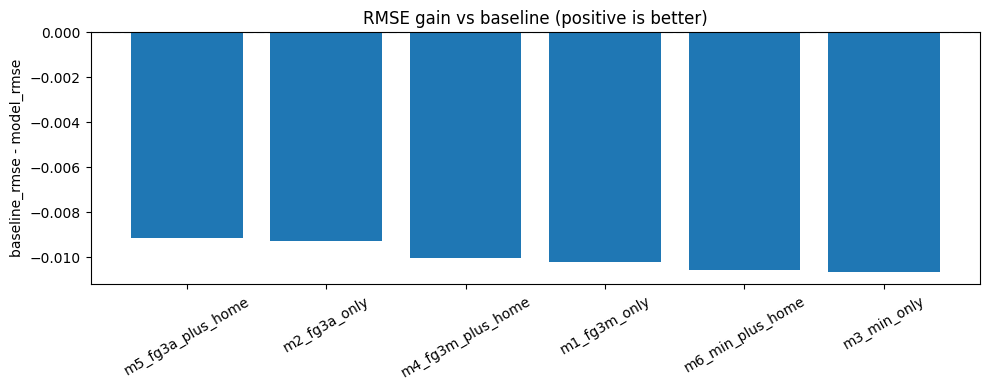

Ellipsis

In [59]:
# Cell 4 — Quick visual of signal lift

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(results["model"], results["rmse_gain_vs_baseline"])
plt.axhline(0, linestyle="--")
plt.title("RMSE gain vs baseline (positive is better)")
plt.ylabel("baseline_rmse - model_rmse")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
...

In [64]:
import numpy as np
import pandas as pd

def build_design_matrix_no_player(frame: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    x_main = frame[feature_cols].to_numpy(dtype=float)
    return np.hstack([np.ones((len(frame), 1), dtype=float), x_main])

def fit_predict_pooled_no_player(train_frame: pd.DataFrame, test_frame: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    X_train = build_design_matrix_no_player(train_frame, feature_cols)
    y_train = train_frame["FG3M"].to_numpy(dtype=float)
    beta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = build_design_matrix_no_player(test_frame, feature_cols)
    y_hat = X_test @ beta
    return np.clip(y_hat, 0.0, None)

def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "r2": r2}

model_specs = [
    ("m1_fg3m_only", ["lag_mean_fg3m"]),
    ("m2_fg3a_only", ["lag_mean_fg3a"]),
    ("m3_min_only", ["lag_mean_min"]),
    ("m4_fg3m_plus_home", ["lag_mean_fg3m", "is_home"]),
    ("m5_fg3a_plus_home", ["lag_mean_fg3a", "is_home"]),
    ("m6_min_plus_home", ["lag_mean_min", "is_home"]),
]

y_test = test_df["FG3M"].to_numpy(dtype=float)
yhat_baseline = test_df["lag_mean_fg3m"].to_numpy(dtype=float)
baseline_metrics = calc_metrics(y_test, yhat_baseline)

rows = []
pred_store = {}

for model_name, feat_cols in model_specs:
    yhat = fit_predict_pooled_no_player(train_df, test_df, feat_cols)
    m = calc_metrics(y_test, yhat)
    rows.append(
        {
            "model": model_name,
            "features": ", ".join(feat_cols),
            "rmse": m["rmse"],
            "mae": m["mae"],
            "r2": m["r2"],
            "rmse_gain_vs_baseline": baseline_metrics["rmse"] - m["rmse"],
            "mae_gain_vs_baseline": baseline_metrics["mae"] - m["mae"],
        }
    )
    pred_store[model_name] = yhat

results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

print("Baseline (lag_mean_fg3m):", baseline_metrics)
results_print = results.copy()
float_cols = results_print.select_dtypes(include=["float64", "float32"]).columns
results_print[float_cols] = results_print[float_cols].round(3)
print(results_print.to_string(index=False))

Baseline (lag_mean_fg3m): {'rmse': 1.921616124641049, 'mae': 1.530275105684726, 'r2': -0.025713714551016453}
            model               features  rmse   mae     r2  rmse_gain_vs_baseline  mae_gain_vs_baseline
m4_fg3m_plus_home lag_mean_fg3m, is_home 1.897 1.505  0.001                  0.025                 0.025
     m1_fg3m_only          lag_mean_fg3m 1.897 1.505  0.001                  0.025                 0.025
m5_fg3a_plus_home lag_mean_fg3a, is_home 1.898 1.516 -0.001                  0.024                 0.014
     m2_fg3a_only          lag_mean_fg3a 1.898 1.516 -0.001                  0.024                 0.014
 m6_min_plus_home  lag_mean_min, is_home 1.916 1.522 -0.020                  0.005                 0.008
      m3_min_only           lag_mean_min 1.917 1.522 -0.020                  0.005                 0.009
